# 04 - APPNP
Gasteiger et al. (2019) - łączy propagację grafową z ideą PageRank.
Węzeł zachowuje własne cechy (teleportacja) zamiast całkowicie polegać na sąsiadach.
Zaprojektowany specjalnie pod semi-supervised learning.

In [1]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import APPNP

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0]
original_train_mask = data.train_mask.clone()

print(f'Węzły:    {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Klasy:    {dataset.num_classes}')

Węzły:    2708
Krawędzie: 10556
Klasy:    7


In [2]:
with open('../models/all_results.json') as f:
    all_raw = json.load(f)

all_results = {
    name: {float(k): v for k, v in res.items()}
    for name, res in all_raw.items()
    if name != 'MLP'
}

ratios = [0.05, 0.10, 0.20]
seeds  = [42, 123, 456, 789, 1000]
labels = ['5%', '10%', '20%']

print('Wyniki wczytane:')
print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name, res in all_results.items():
    row = f'{name:<12}'
    for ratio in ratios:
        row += f'  {np.mean(res[ratio]):.4f}±{np.std(res[ratio]):.4f}'
    print(row)

Wyniki wczytane:
Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.7952±0.0118  0.8218±0.0105  0.8424±0.0156


## Funkcje pomocnicze

In [3]:
def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)

    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]

    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True

    return train_mask

def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

## Architektura APPNP

APPNP rozdziela dwa etapy które w GCN/GAT są połączone:
  1. Transformacja cech - zwykły MLP (fc1, fc2)
  2. Propagacja - APPNP z parametrem alfa (teleportacja)

Parametr alfa (0.1-0.2) kontroluje ile informacji węzeł zachowuje z własnych cech
vs ile pobiera od sąsiadów. Wyższe alfa = silniejszy powrót do własnych cech.

K = liczba kroków propagacji (odpowiednik liczby warstw w GCN).
Dzięki rozdzieleniu etapów można użyć dużego K bez over-smoothing.

In [4]:
class APPNPNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 K=10, alpha=0.1, dropout=0.5):
        super().__init__()
        self.fc1   = torch.nn.Linear(in_channels, hidden_channels)
        self.fc2   = torch.nn.Linear(hidden_channels, out_channels)
        self.prop  = APPNP(K=K, alpha=alpha)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # etap 1: transformacja cech (MLP)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.fc2(x)
        # etap 2: propagacja grafowa z teleportacją
        x = self.prop(x, edge_index)
        return F.log_softmax(x, dim=1)

print('Parametry: K=10 (kroki propagacji), alpha=0.1 (teleportacja)')

Parametry: K=10 (kroki propagacji), alpha=0.1 (teleportacja)


## Baseline - standardowy split Planetoid
Punkt odniesienia do papieru Gasteiger et al. (2019): ok. 83.3% na Corze.

In [5]:
data.train_mask = original_train_mask

baseline_model = APPNPNet(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=dataset.num_classes,
    K=10, alpha=0.1
)
baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(200):
    loss = train(baseline_model, baseline_optimizer)
    if epoch % 20 == 0:
        acc = test(baseline_model)
        print(f'Epoch {epoch:3d}: Loss={loss:.4f}, Acc={acc:.4f}')

baseline_acc = test(baseline_model)
print(f'\nBaseline APPNP (paper split): {baseline_acc:.4f}')
print(f'Paper (Gasteiger 2019): 0.833')

Epoch   0: Loss=1.9438, Acc=0.4940
Epoch  20: Loss=0.0999, Acc=0.8240
Epoch  40: Loss=0.0397, Acc=0.8100
Epoch  60: Loss=0.0316, Acc=0.8110
Epoch  80: Loss=0.0451, Acc=0.8170
Epoch 100: Loss=0.0334, Acc=0.8080
Epoch 120: Loss=0.0217, Acc=0.8230
Epoch 140: Loss=0.0227, Acc=0.8100
Epoch 160: Loss=0.0230, Acc=0.7870
Epoch 180: Loss=0.0157, Acc=0.8180

Baseline APPNP (paper split): 0.8160
Paper (Gasteiger 2019): 0.833


## Eksperymenty - accuracy vs liczba etykiet

In [6]:
appnp_results = defaultdict(list)
best_acc = 0

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)

        model = APPNPNet(
            in_channels=dataset.num_features,
            hidden_channels=64,
            out_channels=dataset.num_classes,
            K=10, alpha=0.1
        )
        optimizer = torch.optim.Adam(
            model.parameters(), lr=0.01, weight_decay=5e-4)

        for epoch in range(200):
            train(model, optimizer)

        acc = test(model)
        appnp_results[ratio].append(acc)
        print(f'APPNP | Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), '../models/appnp_best.pt')

data.train_mask = original_train_mask

print('\n--- Podsumowanie APPNP ---')
for ratio, accs in appnp_results.items():
    print(f'{ratio:.0%}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'Najlepszy model: {best_acc:.4f}')

APPNP | Ratio: 5%, Seed: 42, Acc: 0.8270
APPNP | Ratio: 5%, Seed: 123, Acc: 0.8200
APPNP | Ratio: 5%, Seed: 456, Acc: 0.8120
APPNP | Ratio: 5%, Seed: 789, Acc: 0.8380
APPNP | Ratio: 5%, Seed: 1000, Acc: 0.8110
APPNP | Ratio: 10%, Seed: 42, Acc: 0.8600
APPNP | Ratio: 10%, Seed: 123, Acc: 0.8210
APPNP | Ratio: 10%, Seed: 456, Acc: 0.8420
APPNP | Ratio: 10%, Seed: 789, Acc: 0.8380
APPNP | Ratio: 10%, Seed: 1000, Acc: 0.8350
APPNP | Ratio: 20%, Seed: 42, Acc: 0.8670
APPNP | Ratio: 20%, Seed: 123, Acc: 0.8400
APPNP | Ratio: 20%, Seed: 456, Acc: 0.8600
APPNP | Ratio: 20%, Seed: 789, Acc: 0.8430
APPNP | Ratio: 20%, Seed: 1000, Acc: 0.8650

--- Podsumowanie APPNP ---
5%: 0.8216 ± 0.0101
10%: 0.8392 ± 0.0126
20%: 0.8550 ± 0.0113
Najlepszy model: 0.8670


## Porówananie modeli

In [7]:
all_results['APPNP'] = dict(appnp_results)

print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name, res in all_results.items():
    row = f'{name:<12}'
    for ratio in ratios:
        row += f'  {np.mean(res[ratio]):.4f}±{np.std(res[ratio]):.4f}'
    print(row)

print('\n--- Różnica względem GCN ---')
for name in ['GAT', 'GraphSAGE', 'APPNP']:
    row = f'{name:<12}'
    for ratio in ratios:
        diff = np.mean(all_results[name][ratio]) - np.mean(all_results['GCN'][ratio])
        sign = '+' if diff >= 0 else ''
        row += f'  {sign}{diff:.4f}      '
    print(row)

Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.7952±0.0118  0.8218±0.0105  0.8424±0.0156
APPNP         0.8216±0.0101  0.8392±0.0126  0.8550±0.0113

--- Różnica względem GCN ---
GAT           +0.0136        +0.0056        +0.0174      
GraphSAGE     +0.0030        +0.0066        +0.0150      
APPNP         +0.0294        +0.0240        +0.0276      


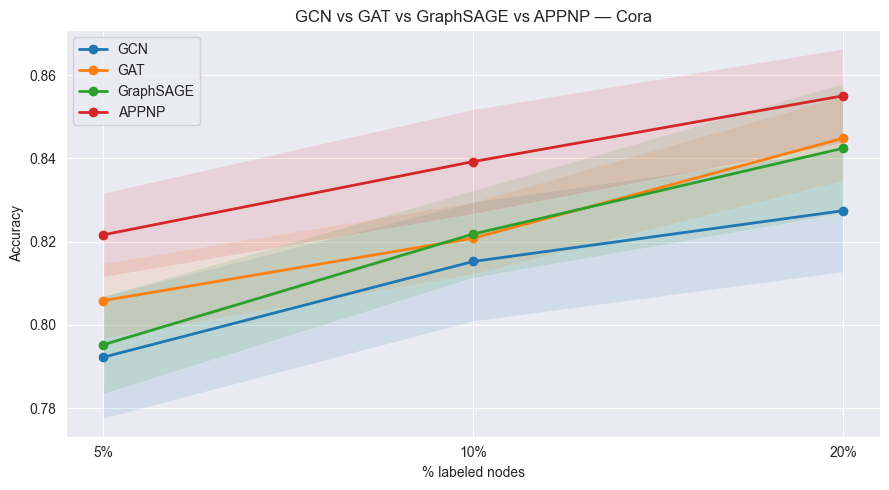

Wykres zapisany: ../results/all_models_with_appnp.png


In [8]:
plt.figure(figsize=(9, 5))
for name, res in all_results.items():
    means = [np.mean(res[r]) for r in ratios]
    stds  = [np.std(res[r])  for r in ratios]
    plt.plot(labels, means,
             marker='o',
             linewidth=2, label=name)
    plt.fill_between(labels,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.12)

plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('GCN vs GAT vs GraphSAGE vs APPNP — Cora')
plt.legend()
plt.tight_layout()
plt.savefig('../results/all_models_with_appnp.png')
plt.show()
print('Wykres zapisany: ../results/all_models_with_appnp.png')

In [9]:
with open('../models/appnp_results.json', 'w') as f:
    json.dump({str(k): v for k, v in appnp_results.items()}, f, indent=2)

all_serializable = {
    name: {str(k): v for k, v in res.items()}
    for name, res in all_results.items()
}
with open('../models/all_results.json', 'w') as f:
    json.dump(all_serializable, f, indent=2)

print('Zapisano:')
print('../models/appnp_results.json')
print('../models/appnp_best.pt')
print('../models/all_results.json  (zaktualizowany o APPNP)')
print('../results/all_models_with_appnp.png')

Zapisano:
../models/appnp_results.json
../models/appnp_best.pt
../models/all_results.json  (zaktualizowany o APPNP)
../results/all_models_with_appnp.png
